In [1]:
import h5py
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

In [2]:
# data_path = "/home/korach/mich/${paths.data_dir}/julie-sim.h5"

data_path = "/home/korach/mich/single_linear_10x10.h5"

In [3]:
with h5py.File(data_path, "r") as file:
    bold = np.stack([file[layer]["bold"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    x = np.stack([file[layer]["x"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    s = np.stack([file[layer]["s"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    f = np.stack([file[layer]["f"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    v = np.stack([file[layer]["v"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    q = np.stack([file[layer]["q"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    v_star = np.stack(
        [file[layer]["v_star"][:50] for layer in file.keys() if "layer" in layer], axis=1
    )
    q_star = np.stack(
        [file[layer]["q_star"][:50] for layer in file.keys() if "layer" in layer], axis=1
    )
    config = json.loads(file["meta"].attrs["config"])

    source_location = file["meta"]["source_layer"][:50]
    source_pos = file["meta"]["source_position"][:50]

In [4]:
print("Data shapes:")
print("BOLD:", bold.shape)
print("x:", x.shape)
print("s:", s.shape)
print("f:", f.shape)
print("v:", v.shape)
print("q:", q.shape)
print("v*:", v_star.shape)
print("q*:", q_star.shape)
print("Config:", config)

Data shapes:
BOLD: (50, 1, 100, 10, 10)
x: (50, 1, 100, 10, 10)
s: (50, 1, 100, 10, 10)
f: (50, 1, 100, 10, 10)
v: (50, 1, 100, 10, 10)
q: (50, 1, 100, 10, 10)
v*: (50, 1, 100, 10, 10)
q*: (50, 1, 100, 10, 10)
Config: {'defaults': ['_self_', {'private': 'private.yaml'}, {'paths': 'default.yaml'}], 'num_simulations': 5000, 'seed': 42, 'output_path': '/home/korach/mich/single_linear_10x10.h5', 'haemodynamic': {'alpha': 0.32, 'E0': 0.34, 'V0': 0.5, 'kappa': 1.92, 'gamma': 0.41}, 'acquisition': {'TE': 0.25, 'r0': 340, 'f0': 28.625, 'eps': 1e-32}, 'simulation': {'num_layers': 1, 'grid_size': [10, 10], 'dt': 1.0, 'haemo_dt': 0.05, 'time_duration': 100, 'max_pulses': 10, 'isi_min': 5, 'pulse_type': 'rect', 'neural_SNR': inf, 'BOLD_SNR': 20.0, 'diffusion_coefficient_intra': 3.0, 'diffusion_coefficient_inter': 0.0, 'decay_rate': 1.0, 'tau_d': 1.0, 'order': 'linear', 'layers': [{'tau': 2.66, 'lambda_d': 0.0}]}, 'bold': {'psf_fwhm': [1.0375], 'noise_model': {'field': '7T', 'V': 8.0, 'TR': 2.0}, '

Source layer: 0, Source position: [2 3]


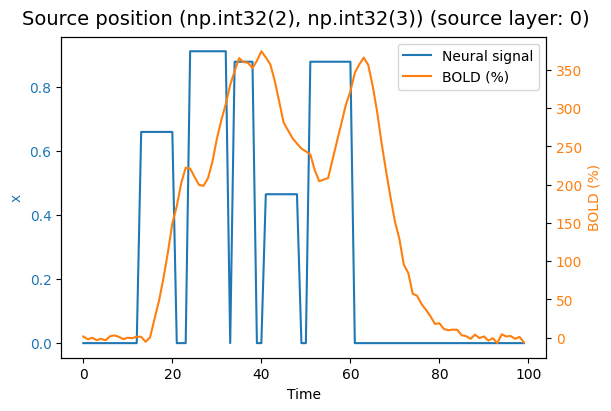

In [5]:
data_idx = np.random.randint(0, bold.shape[0])
slayer = source_location[data_idx]
spos = source_pos[data_idx]
print(f"Source layer: {slayer}, Source position: {spos}")

n_layers = x.shape[1]

fig, ax = plt.subplots(
    nrows=n_layers, ncols=1, figsize=(6, 4), sharex=True, constrained_layout=True
)


x_sig = x[data_idx, 0, :, *spos]
bold_sig = bold[data_idx, 0, :, *spos]

(l1,) = ax.plot(x_sig, color="tab:blue", label="Neural signal")
ax.set_ylabel("x", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax.twinx()
(l2,) = ax2.plot(bold_sig * 100, color="tab:orange", label="BOLD (%)")
ax2.set_ylabel("BOLD (%)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax.legend(handles=[l1, l2], loc="upper right")

ax.set_xlabel("Time")
fig.suptitle(f"Source position {tuple(spos)} (source layer: {slayer})", fontsize=14)
plt.show()

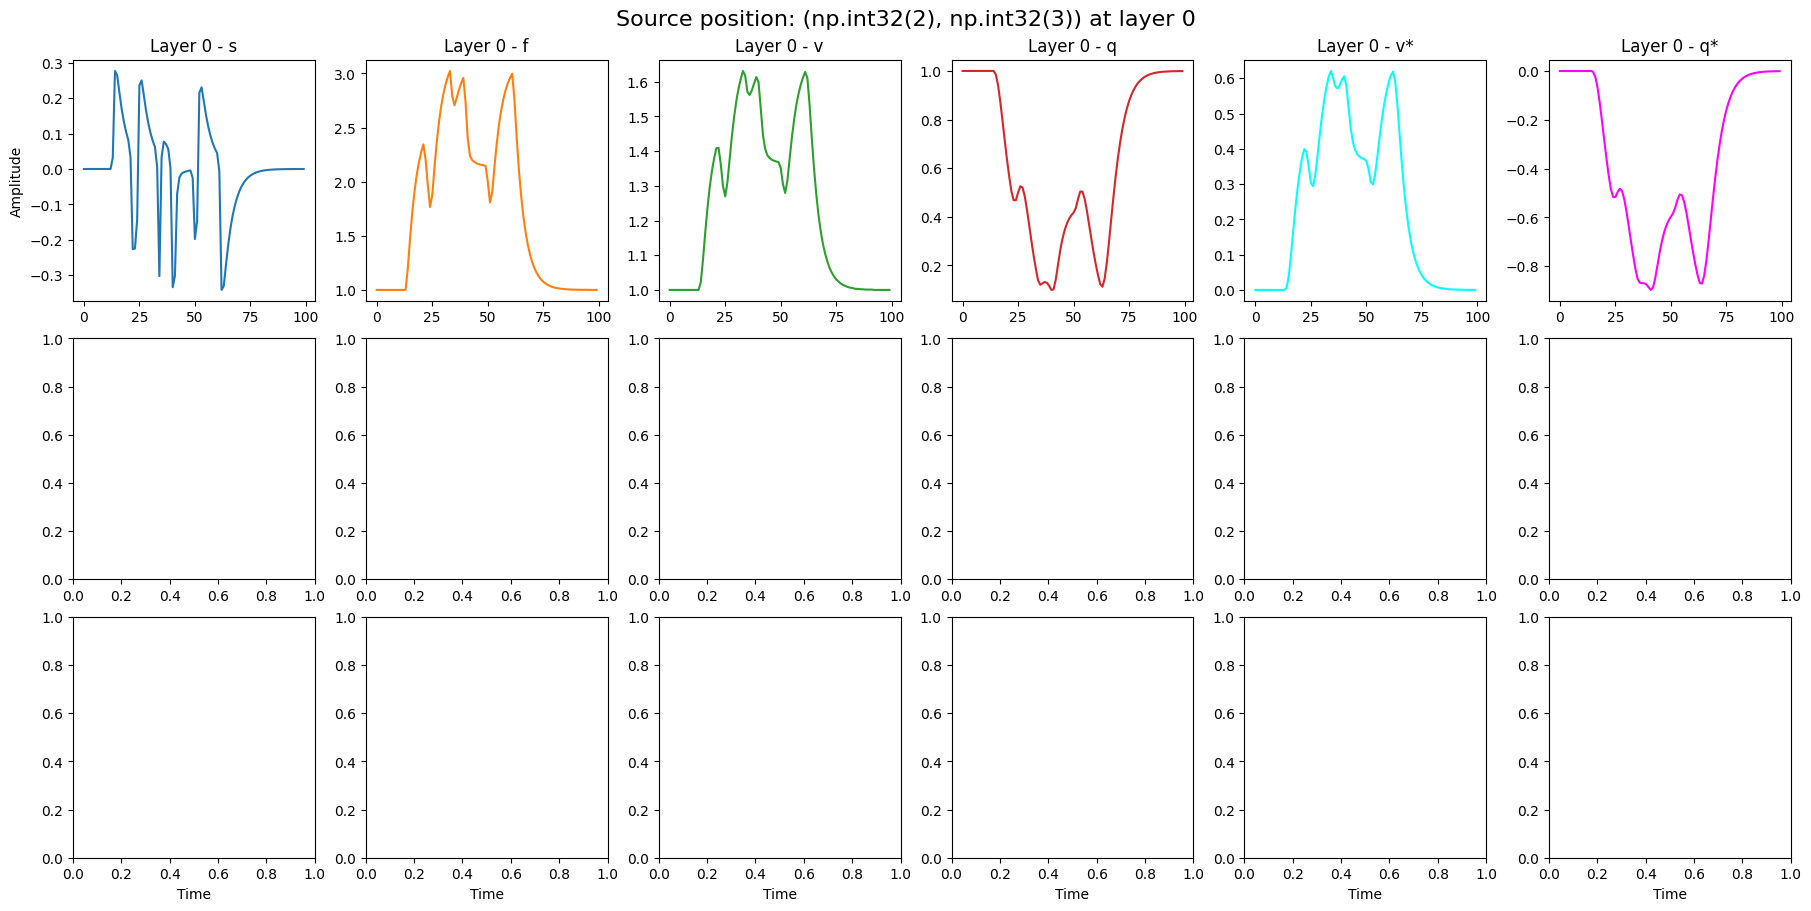

In [6]:
fig, ax = plt.subplots(nrows=3, ncols=6, figsize=(18, 9), constrained_layout=True)

n_layers = s.shape[1]  # expected 3

for i in range(n_layers):
    row = n_layers - 1 - i  # deepest at bottom

    ax[row, 0].plot(s[data_idx, i, :, *spos], color="tab:blue")
    ax[row, 0].set_title(f"Layer {i} - s")

    ax[row, 1].plot(f[data_idx, i, :, *spos], color="tab:orange")
    ax[row, 1].set_title(f"Layer {i} - f")

    ax[row, 2].plot(v[data_idx, i, :, *spos], color="tab:green")
    ax[row, 2].set_title(f"Layer {i} - v")

    ax[row, 3].plot(q[data_idx, i, :, *spos], color="tab:red")
    ax[row, 3].set_title(f"Layer {i} - q")

    ax[row, 4].plot(v_star[data_idx, i, :, *spos], color="cyan")
    ax[row, 4].set_title(f"Layer {i} - v*")

    ax[row, 5].plot(q_star[data_idx, i, :, *spos], color="magenta")
    ax[row, 5].set_title(f"Layer {i} - q*")

for r in range(n_layers):
    ax[r, 0].set_ylabel("Amplitude")
for c in range(6):
    ax[-1, c].set_xlabel("Time")

plt.suptitle(f"Source position: {tuple(spos)} at layer {slayer}", fontsize=16)
plt.show()

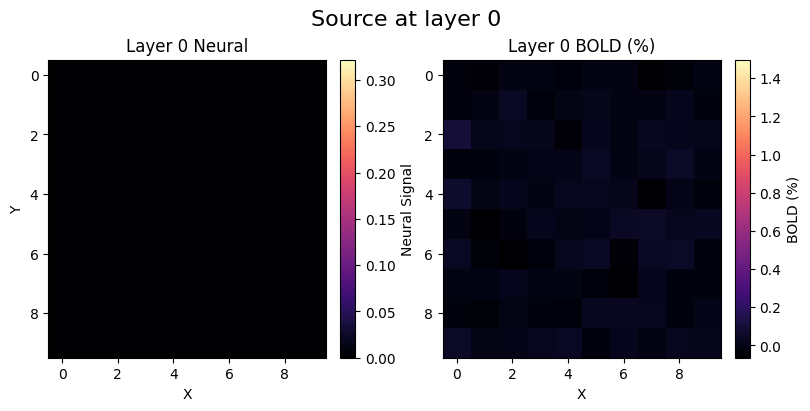

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), constrained_layout=True)

# Use full time dimension (100), not a single time index
bold_sig = bold[data_idx]  # shape: (layers, time, y, x)
neural_sig = x[data_idx]  # shape: (layers, time, y, x)
nlayers = bold_sig.shape[0]

bold_min, bold_max = np.quantile(bold_sig, 0.01), np.quantile(bold_sig, 0.99)
neural_min, neural_max = np.quantile(neural_sig, 0.01), np.quantile(neural_sig, 0.99)

fig.suptitle(f"Source at layer {slayer}", fontsize=16)

# Keep image handles for animation updates
img_neural = []
img_bold = []


n_im = ax[0].imshow(neural_sig[0, 0], aspect="auto", cmap="magma", vmin=neural_min, vmax=neural_max)
b_im = ax[1].imshow(bold_sig[0, 0], aspect="auto", cmap="magma", vmin=bold_min, vmax=bold_max)

img_neural.append(n_im)
img_bold.append(b_im)

ax[0].set_title(f"Layer {i} Neural")
ax[1].set_title(f"Layer {i} BOLD (%)")
ax[0].set_ylabel("Y")

# Add only one colorbar per column
fig.colorbar(img_neural[0], ax=ax[0], orientation="vertical", label="Neural Signal")
fig.colorbar(img_bold[0], ax=ax[1], orientation="vertical", label="BOLD (%)")

for c in range(2):
    ax[c].set_xlabel("X")


def update_frame(t):
    for layer in range(nlayers):
        img_neural[layer].set_data(neural_sig[layer, t])
        img_bold[layer].set_data(bold_sig[layer, t])
    return img_neural + img_bold


ani = FuncAnimation(fig, update_frame, frames=bold_sig.shape[1], repeat=True)
plt.show()

In [8]:
# ani.save("bold_neural_animation.gif", writer="pillow", fps=3)